### This example from Fairlearn -documentation

See the documentation links below for explanations on how to read this.

In a nutshell: we can analyze if any of the sensitive groups/categories are biased/discriminated unfairly. Also mitigation strategies to fix these are represented.

In [1]:
# https://fairlearn.org/v0.11/quickstart.html

# for newest version:
# https://fairlearn.org/v0.13/quickstart.html

In [2]:
# pip install fairlearn

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from fairlearn.datasets import fetch_diabetes_hospital
data = fetch_diabetes_hospital(as_frame=True)
X = data.data.copy()
X.drop(columns=["readmitted", "readmit_binary"], inplace=True)
y = data.target
X_ohe = pd.get_dummies(X)
race = X['race']
race.value_counts()

race
Caucasian          76099
AfricanAmerican    19210
Unknown             2273
Hispanic            2037
Other               1506
Asian                641
Name: count, dtype: int64

In [4]:
from fairlearn.metrics import MetricFrame
from sklearn.metrics import accuracy_score, balanced_accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
np.random.seed(42)  # set seed for consistent results
X_train, X_test, y_train, y_test, A_train, A_test = train_test_split(X_ohe, y, race, random_state=123)
classifier = DecisionTreeClassifier(min_samples_leaf=10, max_depth=4)
classifier.fit(X_train, y_train)

y_pred = (classifier.predict_proba(X_test)[:,1] >= 0.1)
mf = MetricFrame(metrics=accuracy_score, y_true=y_test, y_pred=y_pred, sensitive_features=A_test)
mf.overall.item()
mf.by_group

race
AfricanAmerican    0.530935
Asian              0.658683
Caucasian          0.503535
Hispanic           0.612524
Other              0.591549
Unknown            0.574576
Name: accuracy_score, dtype: float64

In [5]:
from fairlearn.metrics import false_negative_rate
mf = MetricFrame(metrics=false_negative_rate, y_true=y_test, y_pred=y_pred, sensitive_features=A_test)
mf.overall.item()
mf.by_group

race
AfricanAmerican    0.296089
Asian              0.500000
Caucasian          0.308555
Hispanic           0.307692
Other              0.333333
Unknown            0.420000
Name: false_negative_rate, dtype: float64

array([[<Axes: title={'center': 'accuracy'}, xlabel='race'>,
        <Axes: title={'center': 'precision'}, xlabel='race'>,
        <Axes: title={'center': 'false positive rate'}, xlabel='race'>],
       [<Axes: title={'center': 'false negative rate'}, xlabel='race'>,
        <Axes: title={'center': 'selection rate'}, xlabel='race'>,
        <Axes: title={'center': 'count'}, xlabel='race'>],
       [<Axes: xlabel='race'>, <Axes: xlabel='race'>,
        <Axes: xlabel='race'>]], dtype=object)

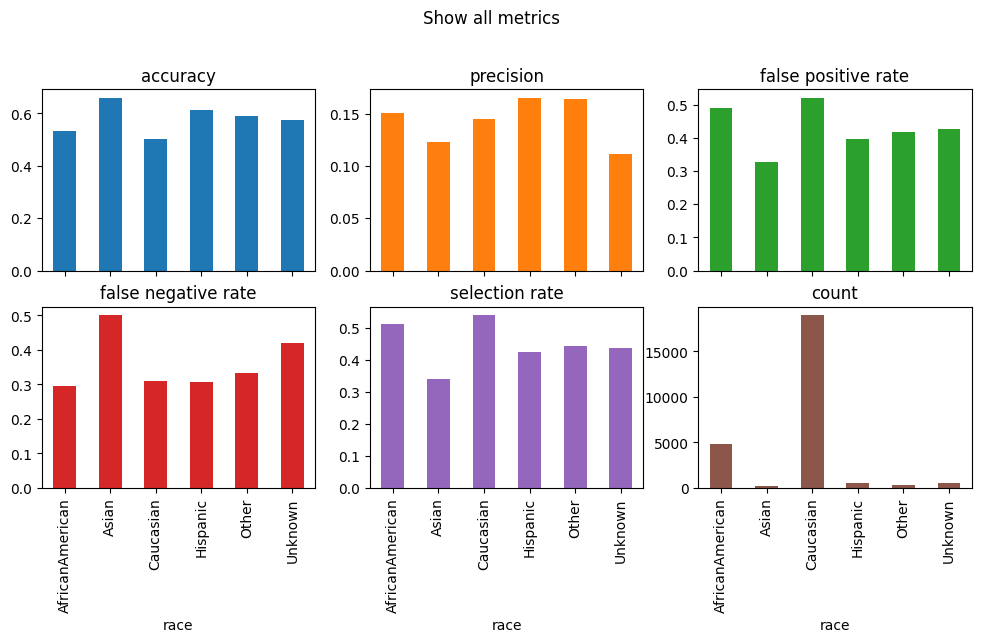

In [6]:
from fairlearn.metrics import false_negative_rate, false_positive_rate, selection_rate, count
from sklearn.metrics import accuracy_score, precision_score
from functools import partial

zero_div_precision_score = partial(precision_score, zero_division=0)

metrics = {
    "accuracy": accuracy_score,
    "precision": zero_div_precision_score,
    "false positive rate": false_positive_rate,
    "false negative rate": false_negative_rate,
    "selection rate": selection_rate,
    "count": count,
}

metric_frame = MetricFrame(
    metrics=metrics, y_true=y_test, y_pred=y_pred, sensitive_features=A_test
)

metric_frame.by_group.plot.bar(
    subplots=True,
    layout=[3, 3],
    legend=False,
    figsize=[12, 8],
    title="Show all metrics",
)

# the usual metrics for FairLearn (there are others though, e.g. disparity metrics)

In [7]:
# apply a mitigation strategy

from fairlearn.reductions import ErrorRate, EqualizedOdds, ExponentiatedGradient
objective = ErrorRate(costs={'fp': 0.1, 'fn': 0.9})
constraint = EqualizedOdds(difference_bound=0.01)
classifier = DecisionTreeClassifier(min_samples_leaf=10, max_depth=4)
mitigator = ExponentiatedGradient(classifier, constraint, objective=objective)
mitigator.fit(X_train, y_train, sensitive_features=A_train)

y_pred_mitigated = mitigator.predict(X_test)
mf_mitigated = MetricFrame(metrics=accuracy_score, y_true=y_test, y_pred=y_pred_mitigated, sensitive_features=A_test)
mf_mitigated.overall.item()

mf_mitigated.by_group

race
AfricanAmerican    0.524358
Asian              0.562874
Caucasian          0.525588
Hispanic           0.549902
Other              0.478873
Unknown            0.511864
Name: accuracy_score, dtype: float64